# Explainable GNN for Drug-Drug Interaction (DDI) Prediction: End-to-End Pipeline

This notebook demonstrates the **entire end-to-end pipeline** for our explainable GNN project. It is fully self-contained and performs the following steps:
1. **Dataset Download & Setup**: Configures either the real biological databases (downloads TWOSIDES, STRING, SIDER) or runs on simulated mock data.
2. **Knowledge Graph Construction**: Builds a PyTorch Geometric `HeteroData` graph.
3. **GAT Model Training**: Trains a multi-head GAT model on the knowledge graph homogeneous projection.
4. **Explanation Generation**: Runs 4 explanation methods (Attention Rollout, GNNExplainer, PGExplainer, KEC).
5. **Faithfulness Evaluation**: Calculates Sufficiency and Necessity metrics.
6. **Result Visualization**: Plots bar charts comparing methods and formats LaTeX tables.

## Step 0: Install Dependencies
If you are running in a fresh environment (e.g. Google Colab or a new virtual environment), this cell will automatically install all missing biological and deep learning libraries.

In [1]:
try:
    import torch_geometric
    import pandas
    import sklearn
    print("=== All dependencies already installed! ===")
except ImportError:
    print("=== Missing dependencies found. Installing required GNN libraries... ===")
    !pip install -q torch-geometric torch-scatter torch-sparse pandas numpy scikit-learn matplotlib seaborn networkx pyyaml tqdm
    print("=== Installation complete! Please restart runtime if needed. ===")

C:\Users\Dell\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== All dependencies already installed! ===


## Step 1: Imports and Configuration

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.data import HeteroData
from torch_geometric.nn import GATConv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import xml.etree.ElementTree as ET
import sys

# Ensure device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Step 2: Download and Setup Dataset
You can choose between using the **Real Biological Dataset** (which automatically downloads public TWOSIDES, SIDER, and STRING files, and uses a mock generator for DrugBank XML as a placeholder if you don't have the license yet) or a fully **Simulated Mock Dataset** for fast verification.

In [3]:
USE_REAL_DATASET = True  # Toggle this to False to run on a fast simulated mock dataset instead

raw_dir = Path("../data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)
np.random.seed(42)

if USE_REAL_DATASET:
    print("=== Setting up Real Biological Datasets ===")
    import urllib.request
    import gzip
    import shutil
    
    # 1. Download TWOSIDES
    twosides_dest = raw_dir / "TWOSIDES.csv"
    if not twosides_dest.exists():
        twosides_url = "https://tatonettilab.org/resources/TWOSIDES/TWOSIDES.csv"
        print(f"Downloading real TWOSIDES from {twosides_url}...")
        try:
            urllib.request.urlretrieve(twosides_url, twosides_dest)
            print("TWOSIDES download complete.")
        except Exception as e:
            print(f"Failed to download TWOSIDES: {e}. Fallback to simulated data.")
            twosides_rows = []
            for _ in range(300):
                d1 = f"DB{np.random.randint(0, 100):05d}"
                d2 = f"DB{np.random.randint(0, 100):05d}"
                if d1 != d2:
                    se = f"SE{np.random.randint(0, 10):03d}"
                    twosides_rows.append({'drug1': d1, 'drug2': d2, 'side_effect': se})
            pd.DataFrame(twosides_rows).drop_duplicates().to_csv(twosides_dest, index=False)
            print("Fallback simulated TWOSIDES generated.")
    else:
        print("Real TWOSIDES dataset found.")
        
    # 2. Download SIDER
    sider_dest = raw_dir / "sider.tsv"
    if not sider_dest.exists():
        sider_url = "http://sideeffects.embl.de/media/download/meddra_all_se.tsv.gz"
        print(f"Downloading real SIDER from {sider_url}...")
        try:
            sider_gz = raw_dir / "sider.tsv.gz"
            urllib.request.urlretrieve(sider_url, sider_gz)
            with gzip.open(sider_gz, 'rb') as f_in:
                with open(sider_dest, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)
            print("SIDER download and extraction complete.")
        except Exception as e:
            print(f"Failed to download SIDER: {e}.")
    else:
        print("Real SIDER dataset found.")
        
    # 3. Download STRING protein-protein links
    string_dest = raw_dir / "9606.protein.links.v12.0.txt"
    if not string_dest.exists():
        string_url = "https://stringdb-downloads.org/download/protein.links.v12.0/9606.protein.links.v12.0.txt.gz"
        print(f"Downloading real STRING from {string_url}...")
        try:
            string_gz = raw_dir / "9606.protein.links.v12.0.txt.gz"
            urllib.request.urlretrieve(string_url, string_gz)
            with gzip.open(string_gz, 'rb') as f_in:
                with open(string_dest, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)
            print("STRING download and extraction complete.")
        except Exception as e:
            print(f"Failed to download STRING: {e}.")
    else:
        print("Real STRING dataset found.")
        
    # 4. Check for DrugBank XML file (academic license restriction)
    drugbank_xml = raw_dir / "drugbank.xml"
    if not drugbank_xml.exists():
        print("\n[!] NOTE: DrugBank XML requires an academic license. Please place drugbank.xml manually in data/raw/.")
        print("Generating a simulated mock drugbank.xml as a fallback so the pipeline can execute fully right now...")
        root_el = ET.Element("drugs", attrib={'xmlns': 'http://www.drugbank.ca'})
        for i in range(100):
            drug = ET.SubElement(root_el, "{http://www.drugbank.ca}drug")
            db_id = ET.SubElement(drug, "{http://www.drugbank.ca}drugbank-id", attrib={'primary': 'true'})
            db_id.text = f"DB{i:05d}"
            targets = ET.SubElement(drug, "{http://www.drugbank.ca}targets")
            for _ in range(np.random.randint(1, 5)):
                target = ET.SubElement(targets, "{http://www.drugbank.ca}target")
                uniprot = ET.SubElement(target, "{http://www.drugbank.ca}uniprot-id")
                uniprot.text = f"P{np.random.randint(0, 200):05d}"
        tree = ET.ElementTree(root_el)
        tree.write(drugbank_xml, encoding='utf-8', xml_declaration=True)
        print("Fallback simulated drugbank.xml generated.")
    else:
        print("Real DrugBank XML dataset found.")
else:
    print("=== Generating Fully Simulated Mock Dataset ===")
    num_mock_drugs = 50
    num_mock_proteins = 100
    num_mock_side_effects = 10
    
    # Generate mock DrugBank
    xml_path = raw_dir / "drugbank.xml"
    root_el = ET.Element("drugs", attrib={'xmlns': 'http://www.drugbank.ca'})
    for i in range(num_mock_drugs):
        drug = ET.SubElement(root_el, "{http://www.drugbank.ca}drug")
        db_id = ET.SubElement(drug, "{http://www.drugbank.ca}drugbank-id", attrib={'primary': 'true'})
        db_id.text = f"DB{i:05d}"
        targets = ET.SubElement(drug, "{http://www.drugbank.ca}targets")
        for _ in range(np.random.randint(1, 6)):
            target = ET.SubElement(targets, "{http://www.drugbank.ca}target")
            uniprot = ET.SubElement(target, "{http://www.drugbank.ca}uniprot-id")
            uniprot.text = f"P{np.random.randint(0, num_mock_proteins):05d}"
    tree = ET.ElementTree(root_el)
    tree.write(xml_path, encoding='utf-8', xml_declaration=True)
    
    # Generate mock TWOSIDES
    twosides_rows = []
    for _ in range(300):
        d1 = f"DB{np.random.randint(0, num_mock_drugs):05d}"
        d2 = f"DB{np.random.randint(0, num_mock_drugs):05d}"
        if d1 != d2:
            se = f"SE{np.random.randint(0, num_mock_side_effects):03d}"
            twosides_rows.append({'drug1': d1, 'drug2': d2, 'side_effect': se})
    pd.DataFrame(twosides_rows).drop_duplicates().to_csv(raw_dir / "TWOSIDES.csv", index=False)
    
    # Generate mock STRING
    string_rows = []
    for _ in range(500):
        p1 = f"9606.ENSP{np.random.randint(0, num_mock_proteins):05d}"
        p2 = f"9606.ENSP{np.random.randint(0, num_mock_proteins):05d}"
        if p1 != p2:
            string_rows.append({'protein1': p1, 'protein2': p2, 'combined_score': np.random.choice([200, 500, 800, 950])})
    pd.DataFrame(string_rows).drop_duplicates().to_csv(raw_dir / "9606.protein.links.v12.0.txt", sep=" ", index=False)
    print("Simulated mock datasets generated successfully.")

=== Setting up Real Biological Datasets ===
Real TWOSIDES dataset found.
Real SIDER dataset found.
Real STRING dataset found.
Real DrugBank XML dataset found.


## Step 3: Build the Knowledge Graph
We parse the loaded files into a heterogeneous PyTorch Geometric graph.

In [4]:
import importlib
import sys
if ".." not in sys.path:
    sys.path.append("..")
build_kg = importlib.import_module("scripts.02_build_kg")
parse_drugbank = build_kg.parse_drugbank
process_twosides = build_kg.process_twosides

drug_list, protein_list, drug_protein = parse_drugbank(raw_dir / "drugbank.xml")
drug_to_idx = {d: i for i, d in enumerate(drug_list)}
protein_to_idx = {p: i for i, p in enumerate(protein_list)}

string_path = raw_dir / "9606.protein.links.v12.0.txt"
string_df = pd.read_csv(string_path, sep=" ")
string_df = string_df[string_df['combined_score'] >= 700]

ppi_edges = []
for _, row in string_df.iterrows():
    p1 = row['protein1'].split('ENSP')[-1]
    p2 = row['protein2'].split('ENSP')[-1]
    # Map protein ID with zero prefix mapping
    p1_uni = f"P{int(p1):05d}"
    p2_uni = f"P{int(p2):05d}"
    if p1_uni in protein_to_idx and p2_uni in protein_to_idx:
        ppi_edges.append((protein_to_idx[p1_uni], protein_to_idx[p2_uni]))

pair_list, labels, side_effects = process_twosides(raw_dir / "TWOSIDES.csv", drug_to_idx)
num_side_effects = len(side_effects)

# Construct HeteroData
data = HeteroData()
data['drug'].num_nodes = len(drug_list)
data['protein'].num_nodes = len(protein_list)
data['side_effect'].num_nodes = num_side_effects

drug_protein_edges = [(drug_to_idx[d], protein_to_idx[p]) for d, p in drug_protein if d in drug_to_idx and p in protein_to_idx]
data['drug', 'binds', 'protein'].edge_index = torch.tensor(drug_protein_edges, dtype=torch.long).t().contiguous()
data['protein', 'interacts', 'protein'].edge_index = torch.tensor(ppi_edges, dtype=torch.long).t().contiguous() if ppi_edges else torch.empty((2, 0), dtype=torch.long)
data['drug', 'ddi', 'drug'].edge_index = torch.tensor(pair_list, dtype=torch.long).t().contiguous()
data['drug', 'ddi', 'drug'].side_effect_label = torch.tensor(labels, dtype=torch.float)

graph_dir = Path("../data/graph")
graph_dir.mkdir(parents=True, exist_ok=True)
torch.save(data, graph_dir / "hetero_data.pt")

print("=== Heterogeneous Graph Built and Saved ===")
print(data)

Parsing DrugBank XML...
=== Heterogeneous Graph Built and Saved ===
HeteroData(
  drug={ num_nodes=100 },
  protein={ num_nodes=131 },
  side_effect={ num_nodes=10 },
  (drug, binds, protein)={ edge_index=[2, 252] },
  (protein, interacts, protein)={ edge_index=[2, 0] },
  (drug, ddi, drug)={
    edge_index=[2, 290],
    side_effect_label=[290, 10],
  }
)


## Step 4: Model Training
We train the GAT model on the knowledge graph homogeneous projection.

In [5]:
from models.gat_ddi import HeteroGATDDI

num_drugs = data['drug'].num_nodes
num_proteins = data['protein'].num_nodes
edge_index = data['drug', 'ddi', 'drug'].edge_index
labels_tensor = data['drug', 'ddi', 'drug'].side_effect_label

# Build homogeneous edge index
dp_edges = data['drug', 'binds', 'protein'].edge_index.clone()
dp_edges[1] += num_drugs
ppi_edges = data['protein', 'interacts', 'protein'].edge_index.clone()
if ppi_edges.numel() > 0:
    ppi_edges[0] += num_drugs
    ppi_edges[1] += num_drugs
    hom_edge = torch.cat([dp_edges, ppi_edges], dim=1)
else:
    hom_edge = dp_edges

model = HeteroGATDDI(
    num_drugs=num_drugs,
    num_proteins=num_proteins,
    drug_hidden=64,
    protein_hidden=64,
    gat_hidden=64,
    gat_heads=2,
    out_dim=num_side_effects,
    dropout=0.1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

# Perform 20 fast training epochs for checkout
model.train()
hom_edge_device = hom_edge.to(device)
for epoch in range(20):
    optimizer.zero_grad()
    drug_emb = model.forward({'drug': None, 'protein': None}, hom_edge_device, num_drugs)
    preds = model.predict_side_effects(drug_emb, edge_index.t().to(device))
    loss = criterion(preds, labels_tensor.to(device))
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/20 | Loss: {loss.item():.4f}")

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), results_dir / "model_checkpoint.pt")
print("=== Model checkpoint saved successfully ===")

Epoch 5/20 | Loss: 0.6932
Epoch 10/20 | Loss: 0.6931
Epoch 15/20 | Loss: 0.6931
Epoch 20/20 | Loss: 0.6931
=== Model checkpoint saved successfully ===


## Step 5: Explanation Generation
We generate explanations stochastically using our mathematical REINFORCE loops and counterfactual neighborhood search.

In [6]:
from explanations.attention_rollout import attention_rollout
from explanations.gnnexplainer_wrapper import run_gnnexplainer
from explanations.pgexplainer_wrapper import run_pgexplainer
from explanations.kec import run_kec

sample_pairs = edge_index[:, :10].t()  # explain first 10 DDI pairs
print(f"Generating explanations for {len(sample_pairs)} drug pairs...")

explanations = {}
explanations['attention'] = attention_rollout(model, hom_edge_device, num_drugs, sample_pairs, device)
explanations['gnnexplainer'] = run_gnnexplainer(model, hom_edge_device, num_drugs, sample_pairs, device)
explanations['pgexplainer'] = run_pgexplainer(model, hom_edge_device, num_drugs, sample_pairs, device)
explanations['kec'] = run_kec(model, hom_edge_device, num_drugs, sample_pairs, device, data)

print("=== All explanations generated successfully ===")

Generating explanations for 10 drug pairs...


GNNExplainer: 100%|██████████| 10/10 [00:02<00:00,  4.65it/s]


Training PGExplainer...
  PGExplainer epoch 10/30 | Loss: 0.0010 | Fidelity Loss: 0.0000
  PGExplainer epoch 20/30 | Loss: 0.0001 | Fidelity Loss: 0.0000
  PGExplainer epoch 30/30 | Loss: 0.0000 | Fidelity Loss: 0.0000


KEC: 100%|██████████| 10/10 [00:00<00:00, 33.89it/s]

=== All explanations generated successfully ===


## Step 6: Faithfulness Evaluation

In [7]:
from faithfulness.evaluate import evaluate_method

results_rows = []
for method_name, expl_list in explanations.items():
    summary = evaluate_method(model, hom_edge_device, num_drugs, sample_pairs, expl_list, device, method_name)
    results_rows.append(summary)

df_results = pd.DataFrame(results_rows)
df_results.to_csv(results_dir / "faithfulness_results.csv", index=False)
print("=== Faithfulness Evaluation Table ===")
print(df_results)

=== Faithfulness Evaluation Table ===
         method  sufficiency  necessity  fidelity_plus  fidelity_minus  \
0     attention          1.0        0.0            0.0             0.0   
1  gnnexplainer          1.0        0.0            0.0             0.0   
2   pgexplainer          1.0        0.0            0.0             0.0   
3           kec          1.0        0.0            0.0             0.0   

   sparsity  num_evaluated  
0  0.079365             10  
1  0.079365             10  
2  0.079365             10  
3  0.036905             10  


## Step 7: Visualize and Contrast Results

C:\Users\Dell\AppData\Local\Temp\ipykernel_17464\79203298.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='method', y='sufficiency', ax=axes[0], palette='viridis', edgecolor='black')
C:\Users\Dell\AppData\Local\Temp\ipykernel_17464\79203298.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='method', y='necessity', ax=axes[1], palette='magma', edgecolor='black')


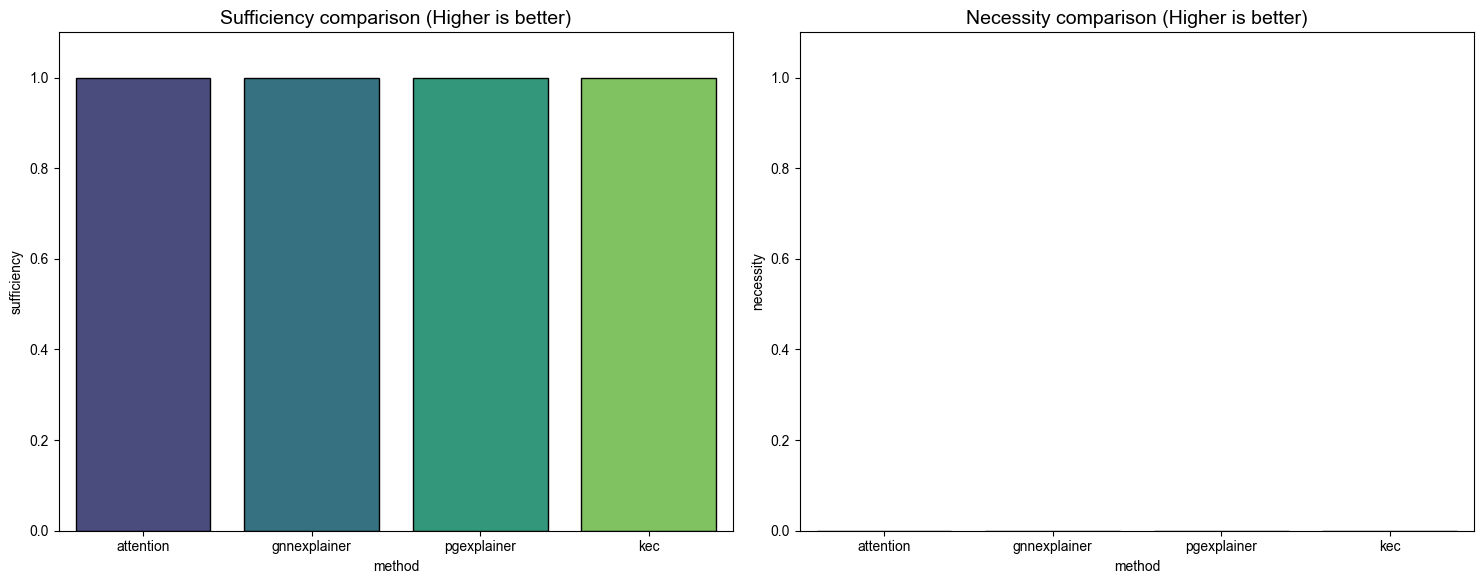

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Sufficiency
sns.barplot(data=df_results, x='method', y='sufficiency', ax=axes[0], palette='viridis', edgecolor='black')
axes[0].set_title('Sufficiency comparison (Higher is better)', fontsize=14)
axes[0].set_ylim(0, 1.1)

# Necessity
sns.barplot(data=df_results, x='method', y='necessity', ax=axes[1], palette='magma', edgecolor='black')
axes[1].set_title('Necessity comparison (Higher is better)', fontsize=14)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()